# 📊 Visualizações — Análise da Cana-de-Açúcar
## Fonte: CONAB — Companhia Nacional de Abastecimento

---

| | |
|---|---|
| 📅 **Safras** | 2017/18 a 2025/26 |
| 📊 **Fonte** | CONAB — Levantamentos Oficiais |
| 📈 **Notebook** | 03 — Visualizações e Gráficos |

---

> **Objetivo:** Gerar visualizações da evolução da produção, área plantada, qualidade (ATR)
> e derivados (açúcar e etanol) da cana-de-açúcar brasileira ao longo das safras,
> com foco em comparações regionais e tendências por estado (UF).

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import geopandas as gpd
import seaborn as sns
import ssl
import kaleido
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from IPython.display import Image
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/cana_limpo.csv', encoding='utf-8')
df_all = pd.read_csv('../data/processed/cana_todos_levantamentos.csv', encoding='utf-8')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print('Bibliotecas prontas!')

Bibliotecas prontas!


## 1. Produção total por safra

In [2]:
prod_safra = df.groupby('ano_agricola')['producao_mil_t'].sum().reset_index()

fig = px.bar(
    prod_safra, x='ano_agricola', y='producao_mil_t',
    title='Produção Total de Cana-de-Açúcar por Safra (mil t)',
    labels={'ano_agricola':'Safra','producao_mil_t':'Produção (mil t)'},
    color='producao_mil_t', color_continuous_scale='Greens',
    text_auto='.0f'
)
fig.update_layout(showlegend=False)
fig.show()
fig.write_image('../reports/figures/01_producao_por_safra.png', width=1000, height=500, scale=2)


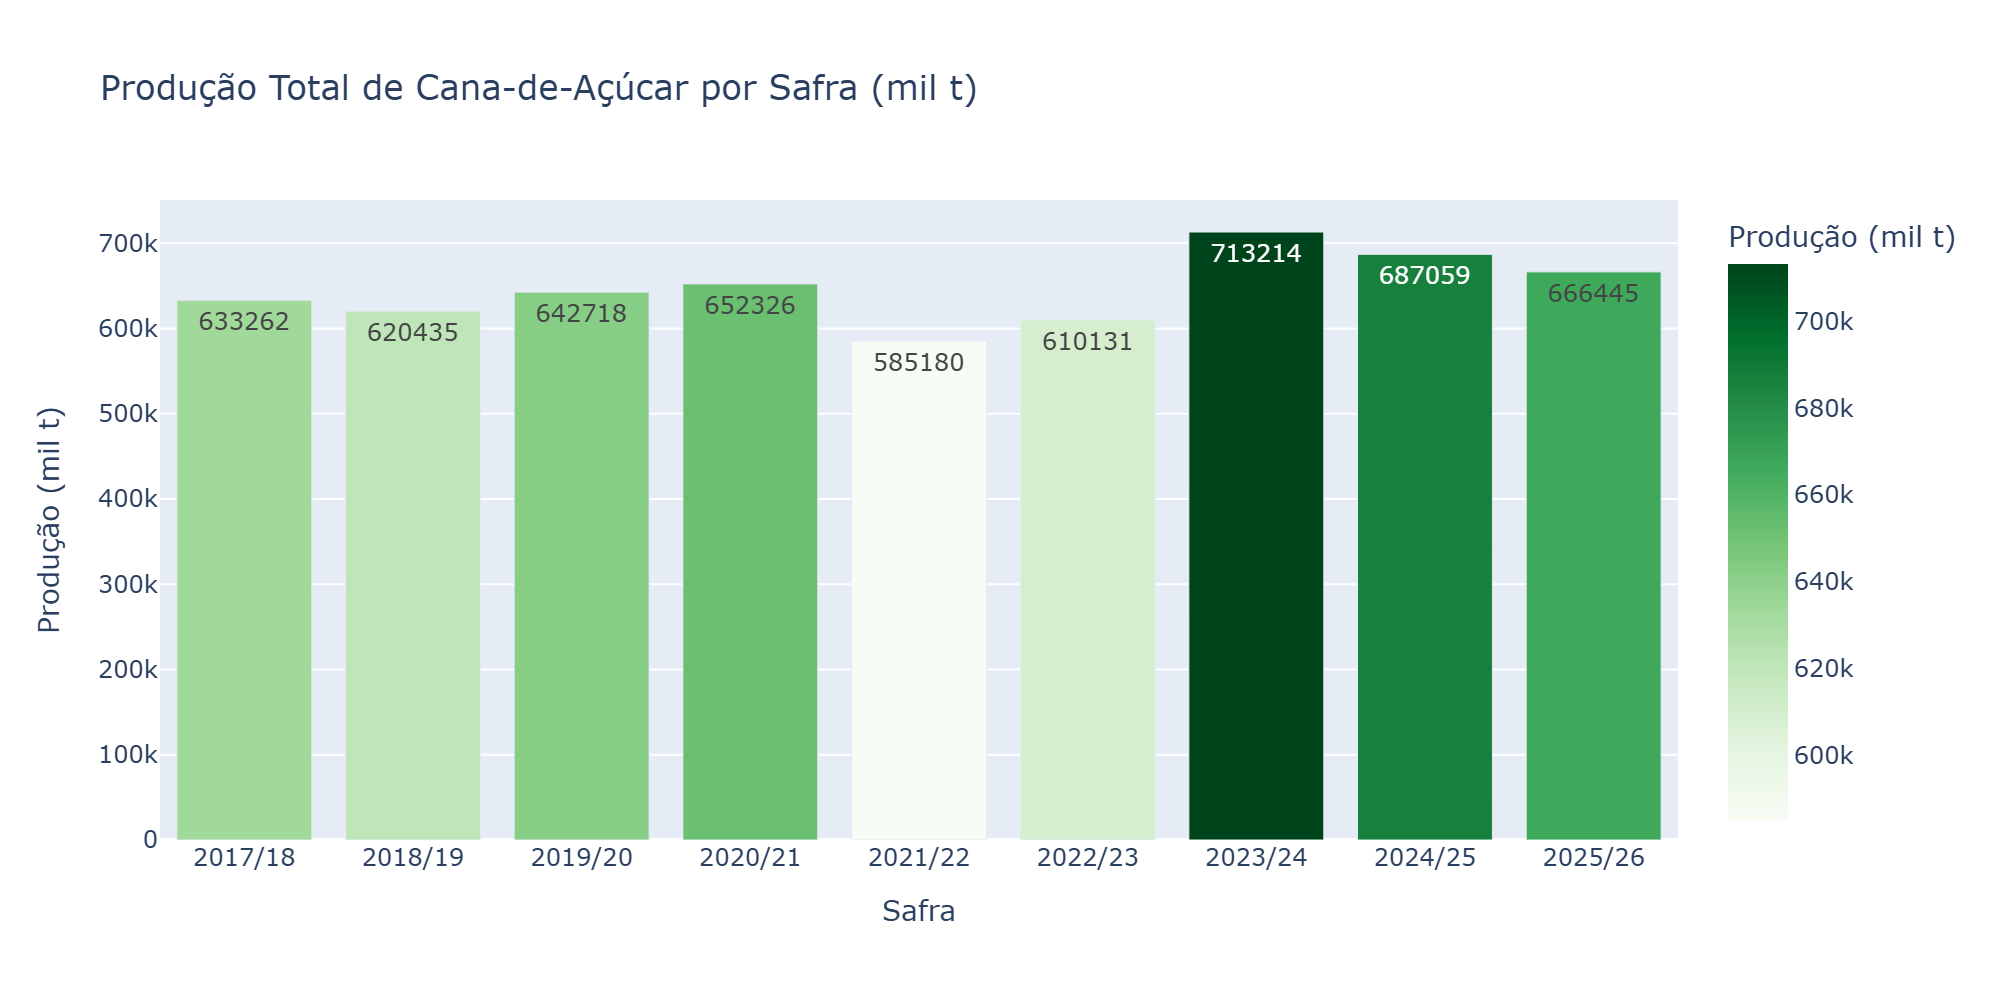

In [7]:
Image('../reports/figures/01_producao_por_safra.png', width=800)

### 📌 Insights — Produção Total por Safra

- **2023/24** registrou o **maior volume** do período: **713.214 mil t**, um crescimento de ~17% sobre a safra anterior
- **2021/22** foi o **pior ano** da série, com queda para **585.180 mil t** — reflexo de adversidades climáticas (geada + seca)
- Após a queda em 2021/22, o setor demonstrou **forte recuperação**, atingindo novo recorde em 2023/24
- A safra **2025/26** apresenta leve recuo em relação ao pico, mas mantém patamar **acima da média histórica**

> 💡 **Tendência geral:** crescimento consistente ao longo do período, com resiliência do setor mesmo após choques climáticos.

---

## 2. Top 10 estados produtores

In [11]:
top10 = df.groupby('uf')['producao_mil_t'].sum().nlargest(10).reset_index()
top10_sorted = top10.sort_values('producao_mil_t')

fig = px.bar(
    top10_sorted,
    x='producao_mil_t',
    y='uf',
    orientation='h',
    title='Top 10 Estados — Produção Acumulada de Cana (mil t)',
    labels={'uf': 'Estado', 'producao_mil_t': 'Produção acumulada (mil t)'},
    color='producao_mil_t',
    color_continuous_scale='YlGn',
    text=top10_sorted['producao_mil_t'].apply(lambda x: f'{x:,.1f}'.replace(',', '.')),
)

fig.update_traces(
    textposition='outside',
    textfont=dict(size=11, color='#333'),
    cliponaxis=False,
)

fig.update_layout(
    showlegend=False,
    coloraxis_showscale=False,
    plot_bgcolor='rgba(240,240,240,0.3)',
    paper_bgcolor='white',
    title=dict(font=dict(size=16)),
    margin=dict(t=70, b=50, l=60, r=120),  # margem direita para rótulos externos
    xaxis=dict(
        showgrid=True,
        gridcolor='rgba(0,0,0,0.08)',
        showticklabels=False,  # rótulos nas barras tornam o eixo X redundante
        title=None,
    ),
    yaxis=dict(showgrid=False, title=None, tickfont=dict(size=12)),
)

fig.update_xaxes(range=[0, top10_sorted['producao_mil_t'].max() * 1.18])

fig.show()
fig.write_image('../reports/figures/02_top10_estados.png', width=1000, height=500, scale=2)

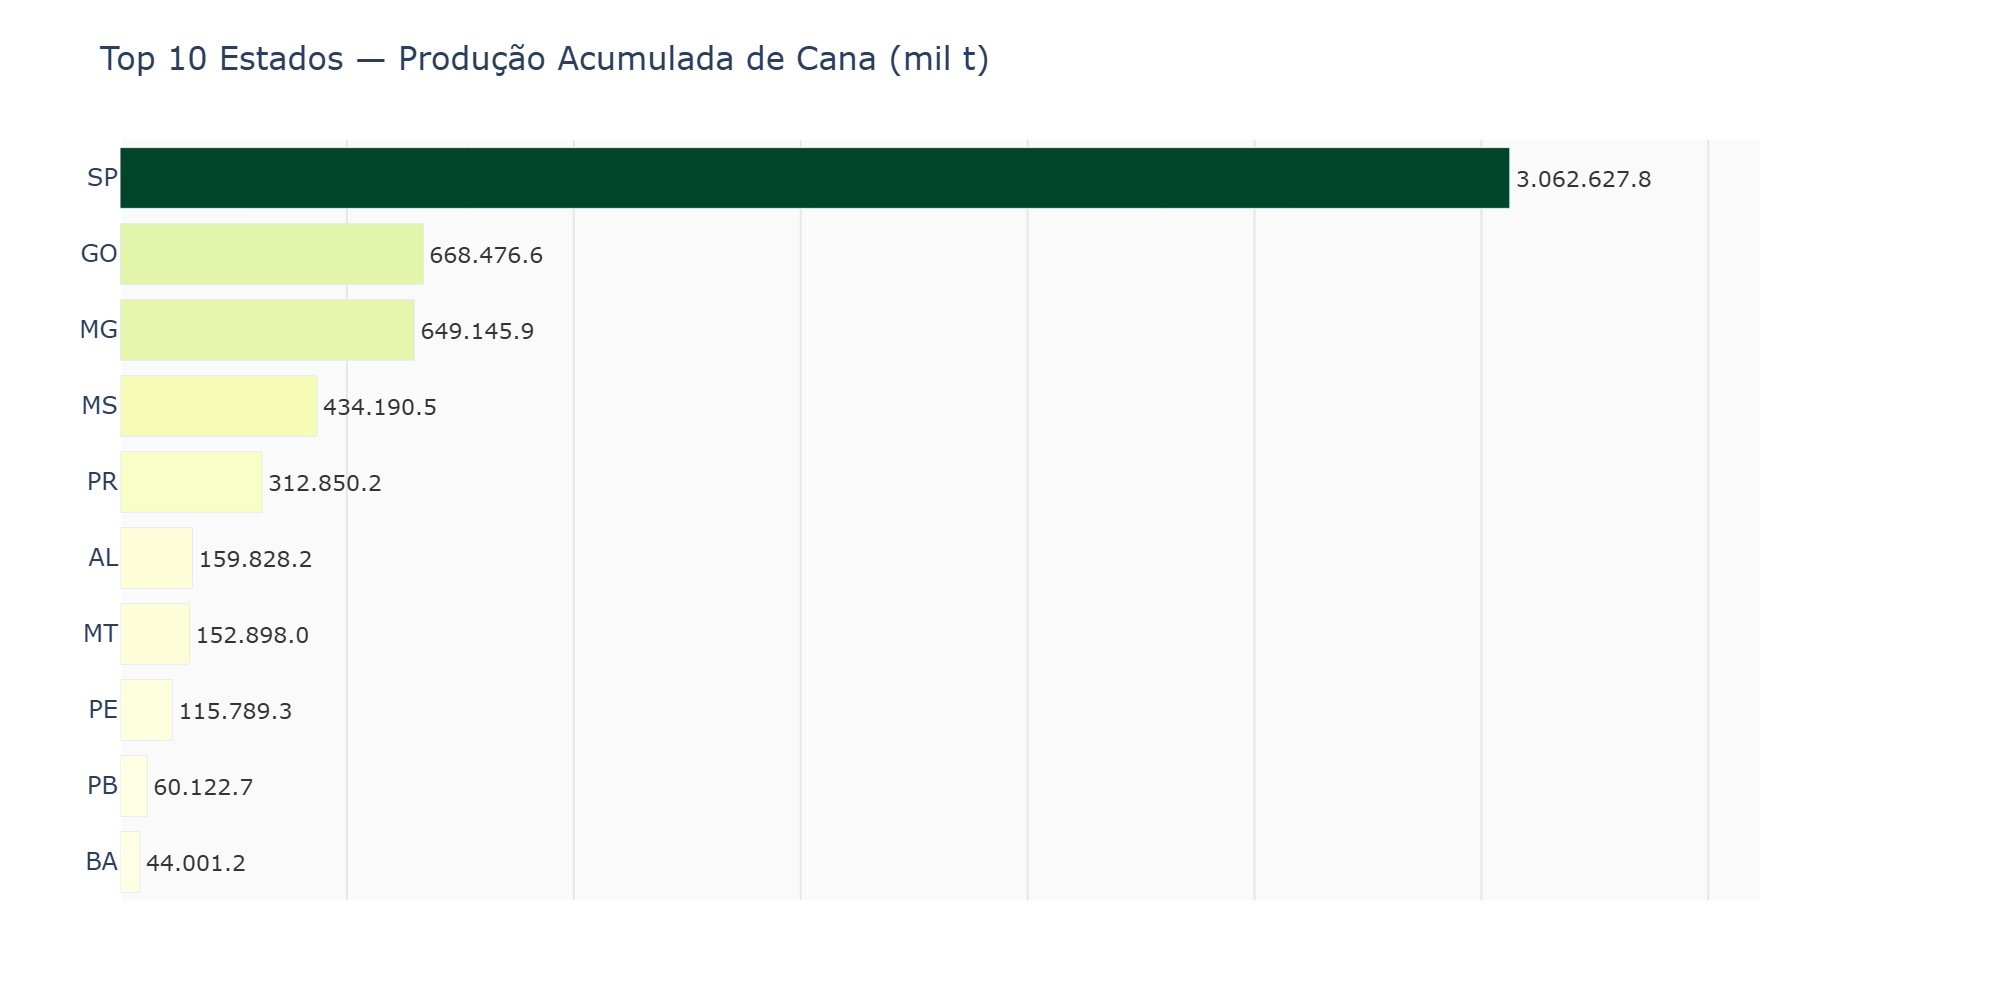

In [12]:
Image('../reports/figures/02_top10_estados.png', width=800)

### 📌 Insights — Produção Acumulada por Estado (UF)

- **SP** registrou a **maior produção acumulada** do ranking: **3.062.627,8 mil t**, representando sozinho mais de **58% do total** do Top 10
- **GO e MG** formam o **segundo bloco**, com 668.476,6 e 649.145,9 mil t respectivamente — produções similares entre si, porém **4,6x menores** que SP
- **MS e PR** ocupam a **faixa intermediária**, com 434.190,5 e 312.850,2 mil t — estados em expansão no Centro-Sul com crescente participação nacional
- **AL e PE** representam o **Nordeste** no ranking, com 159.828,2 e 115.789,3 mil t — presença histórica, mas com escala menor frente ao eixo Centro-Sul
- **MT, PB, BA e RN** fecham o Top 10 com produções abaixo de **153 mil t**, sinalizando participação ainda **incipiente no acumulado**

> 💡 **Tendência geral:** produção nacional fortemente concentrada no Centro-Sul, com SP como protagonista isolado — padrão que reflete décadas de expansão agroindustrial no estado.

---

## 3. Açúcar vs Etanol por safra

In [9]:
ae = df.groupby('ano_agricola').agg(
    acucar=('producao_acucar_mil_t', 'sum'),
    etanol=('producao_etanol_total_mil_l', 'sum')
).reset_index()
ae['etanol_bil_l'] = (ae['etanol'] / 1_000_000).round(2)

fig = make_subplots(specs=[[{'secondary_y': True}]])

# Barras de açúcar com rótulos
fig.add_trace(
    go.Bar(
        x=ae['ano_agricola'],
        y=ae['acucar'],
        name='Açúcar (mil t)',
        marker_color='#f4a261',
        text=ae['acucar'].apply(lambda x: f'{x:,.0f}'.replace(',', '.')),
        textposition='outside',
        textfont=dict(size=11, color='#f4a261'),
        cliponaxis=False,
    ),
    secondary_y=False,
)

# Linha de etanol com rótulos
fig.add_trace(
    go.Scatter(
        x=ae['ano_agricola'],
        y=ae['etanol_bil_l'],
        name='Etanol (bilhões L)',
        mode='lines+markers+text',
        line=dict(color='#2196F3', width=2),
        marker=dict(size=7),
        text=ae['etanol_bil_l'].apply(lambda x: f'{x:.2f}'),
        textposition='top center',
        textfont=dict(size=11, color='#2196F3'),
        cliponaxis=False,
    ),
    secondary_y=True,
)

fig.update_layout(
    title=dict(text='Produção de Açúcar e Etanol por Safra', font=dict(size=16)),
    plot_bgcolor='rgba(240,240,240,0.3)',
    paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(t=80, b=60, l=70, r=70),
    bargap=0.3,
)

fig.update_yaxes(
    title_text='Açúcar (mil t)',
    secondary_y=False,
    range=[0, ae['acucar'].max() * 1.25],  # espaço para rótulos acima das barras
    showgrid=True,
    gridcolor='rgba(0,0,0,0.08)',
)
fig.update_yaxes(
    title_text='Etanol (bilhões L)',
    secondary_y=True,
    range=[ae['etanol_bil_l'].min() * 0.92, ae['etanol_bil_l'].max() * 1.12],
    showgrid=False,
)
fig.update_xaxes(showgrid=False)

fig.show()
fig.write_image('../reports/figures/03_acucar_vs_etanol.png', width=1200, height=550, scale=2)

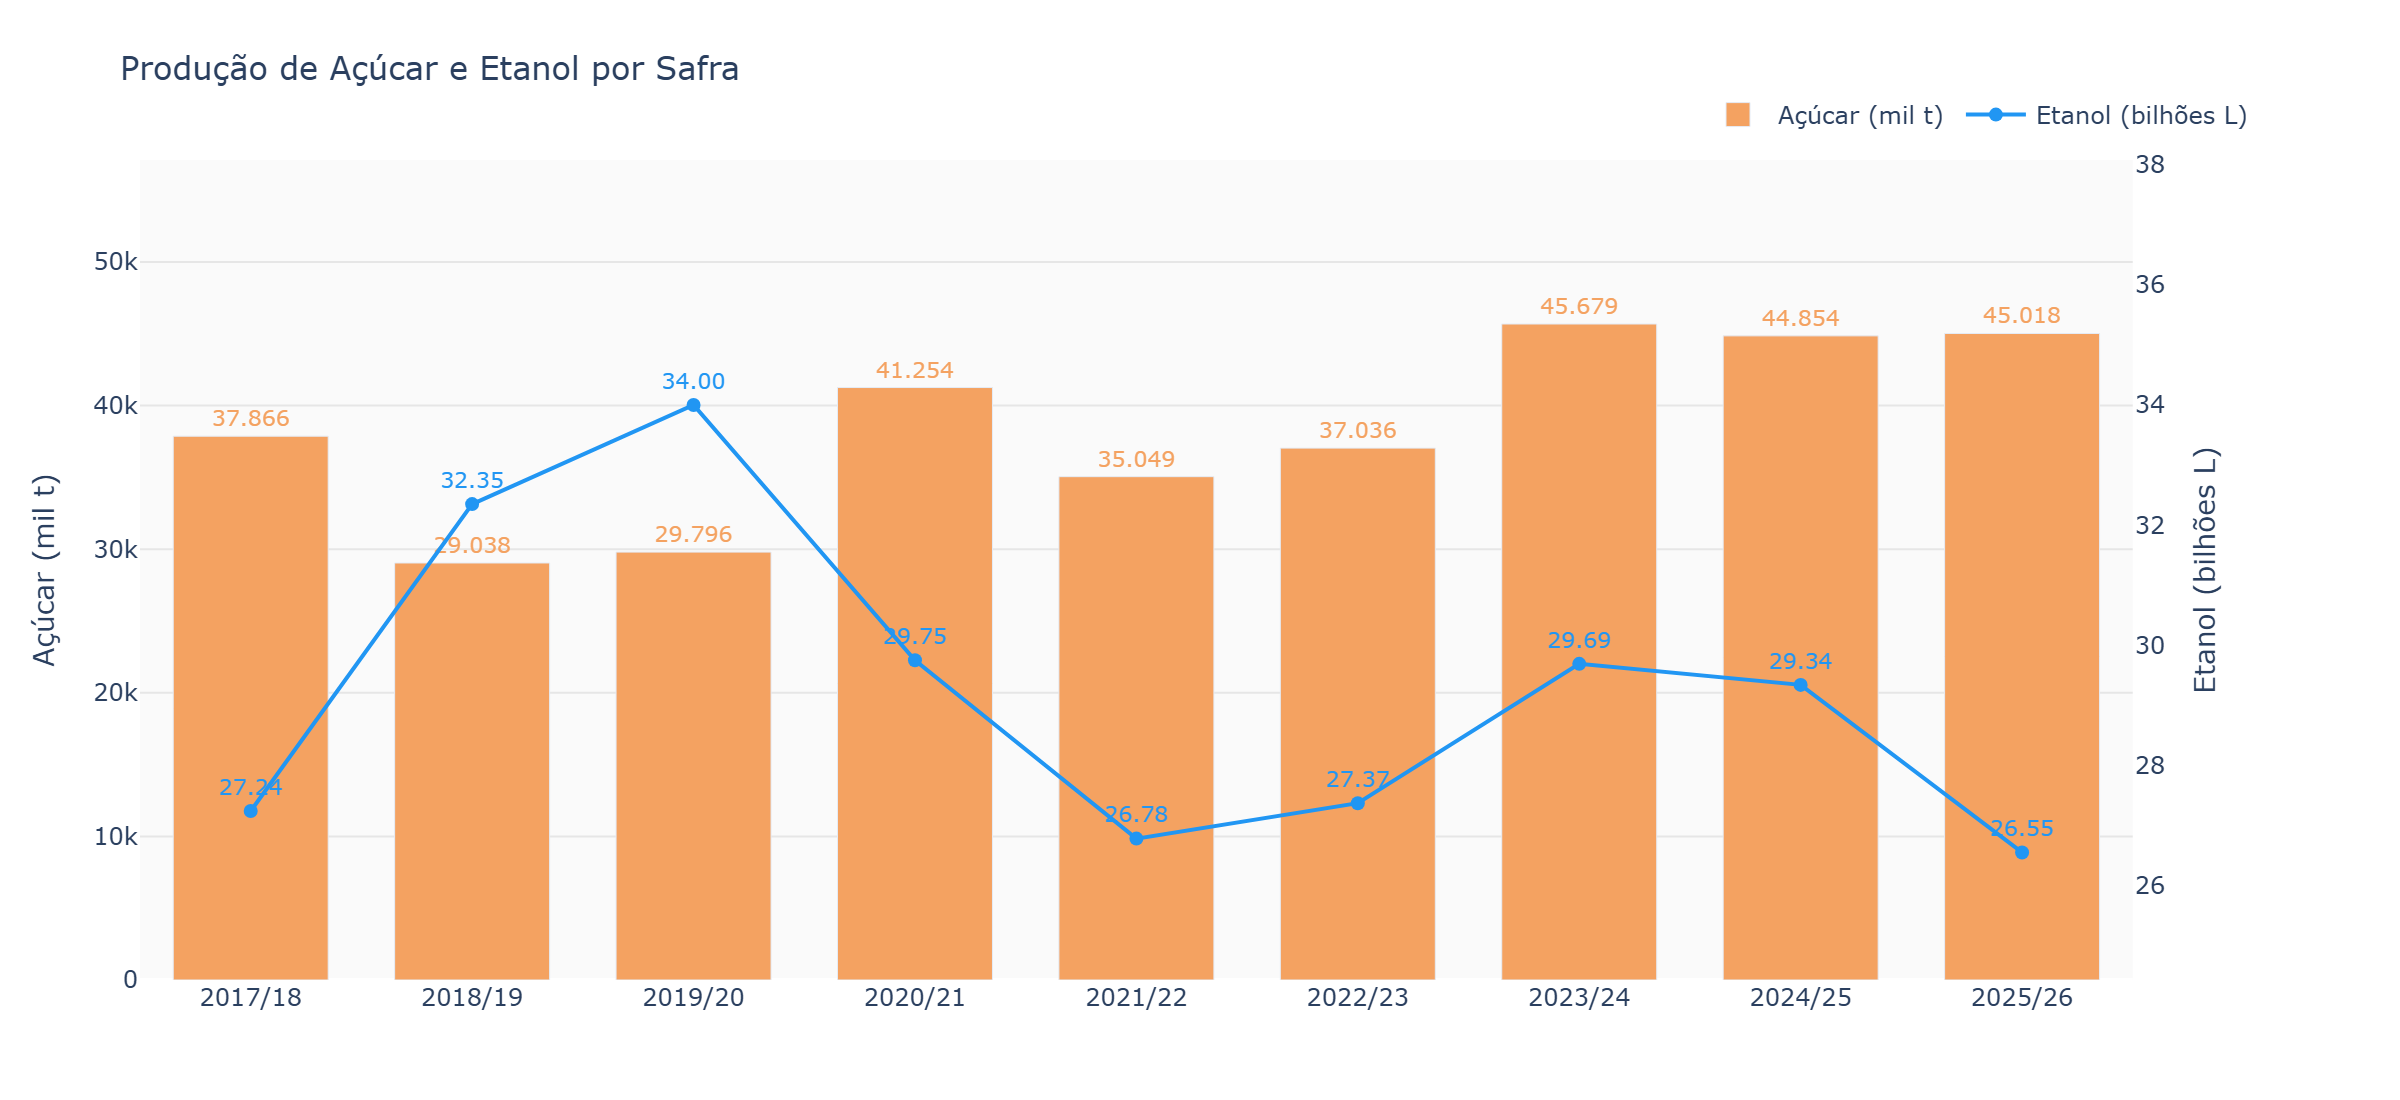

In [10]:
Image('../reports/figures/03_acucar_vs_etanol.png', width=800)

### 📌 Insights — Açúcar vs Etanol por Safra

- **2023/24** registrou o **pico histórico de açúcar**: **45.678,8 mil t** — maior volume das 8 safras, superando em +10,7% o segundo colocado (2024/25, 44.853,6 mil t), sinalizando dois anos consecutivos de recorde no segmento sólido
- **2019/20** concentrou a **máxima de etanol**: **34,00 bilhões de litros** — após a quebra de 2017/18 (27,24 bi L), o setor acelerou a conversão de cana para líquido, atingindo o topo do período analisado
- **2021/22 foi o piso duplo**: menor produção de açúcar (35.049,1 mil t) e de etanol (26,78 bi L) no ciclo — reflexo de adversidades climáticas e queda na disponibilidade de cana na região Centro-Sul
- A **proporção de cana para etanol oscilou entre 26,78% e 34,00%**, com média de ~29,8% — variação relativamente estreita, indicando que a flexibilidade produtiva das usinas (flex) absorve choques sem grandes desvios estruturais
- **Trajetória pós-2021/22**: ambos os indicadores se recuperam em conjunto, mas com dinâmicas distintas — açúcar em alta consistente (+30,3%), etanol em recuperação moderada (+9,6%), sugerindo **viés crescente de alocação para o sólido** nas safras recentes

> 💡 **Tendência geral:** o setor sucroenergético demonstra resiliência cíclica, com picos alternados entre açúcar e etanol conforme incentivos de preço — mas a aceleração pós-2022/23 no açúcar aponta para uma janela de rentabilidade que tem puxado a alocação produtiva para esse lado da balança.

---

## 4. ATR médio por safra e por estado

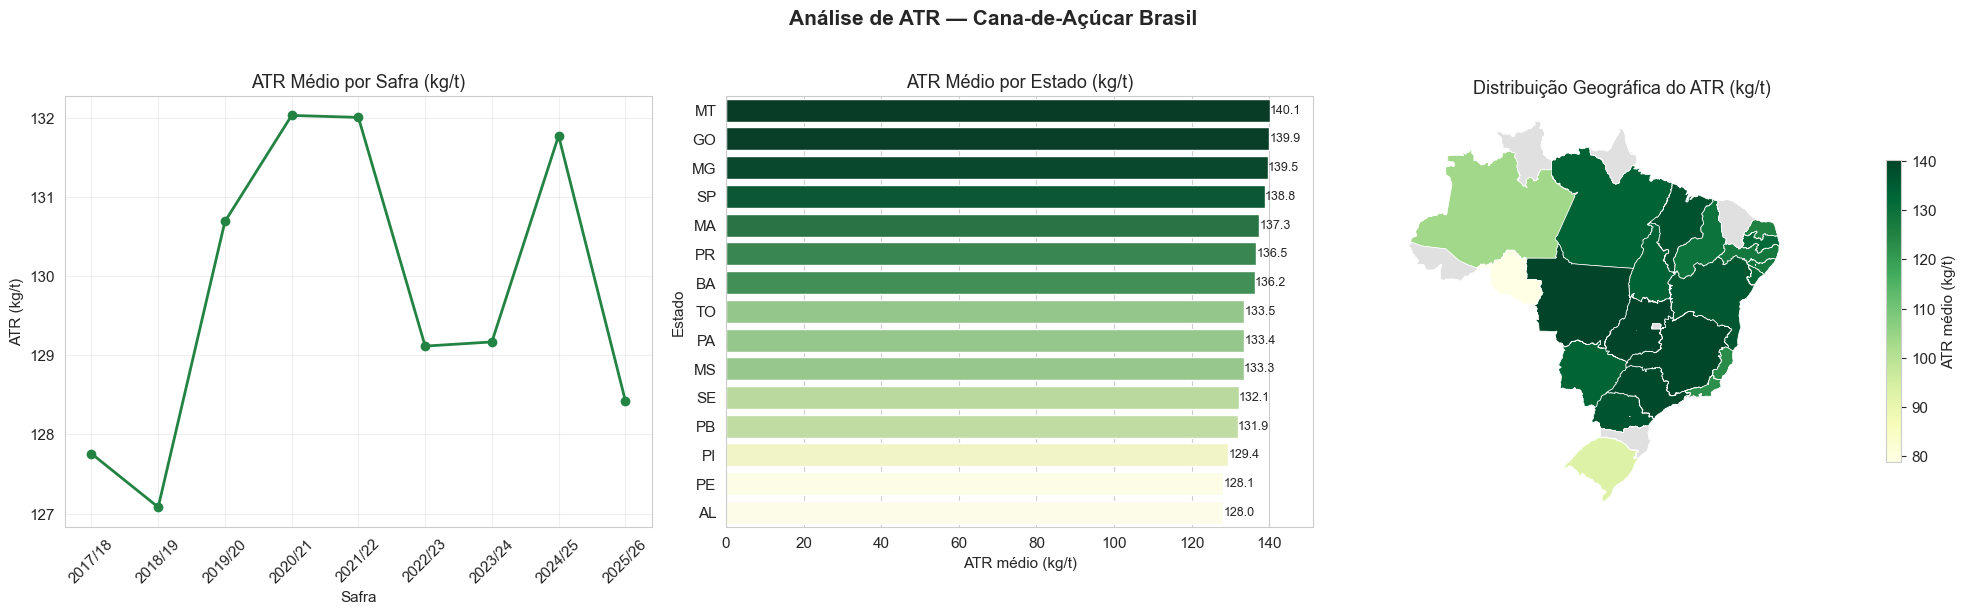

In [30]:
# --- dados ---
atr_safra  = df.groupby('ano_agricola')['produtcao_atr_kg_t'].mean().reset_index()
atr_estado = df.groupby('uf')['produtcao_atr_kg_t'].mean().reset_index()
atr_estado.columns = ['uf', 'atr_medio']

# --- shapefile local ---
gdf = gpd.read_file('../data/raw/BR_UF_2022.zip')
gdf = gdf.merge(atr_estado, left_on='SIGLA_UF', right_on='uf', how='left')

# --- paleta de referência extraída do cmap YlGn ---
cmap      = cm.get_cmap('YlGn')
cor_linha = mcolors.to_hex(cmap(0.75))

atr_top15  = atr_estado.sort_values('atr_medio', ascending=False).head(15)
norm       = mcolors.Normalize(vmin=atr_top15['atr_medio'].min(),
                               vmax=atr_top15['atr_medio'].max())
cor_barras = [mcolors.to_hex(cmap(norm(v))) for v in atr_top15['atr_medio']]

# --- layout ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Linha — ATR por safra
axes[0].plot(
    atr_safra['ano_agricola'], atr_safra['produtcao_atr_kg_t'],
    marker='o', color=cor_linha, linewidth=2
)
axes[0].set_title('ATR Médio por Safra (kg/t)', fontsize=13)
axes[0].set_xlabel('Safra')
axes[0].set_ylabel('ATR (kg/t)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# 2. Barras — Top 15 estados
bars = sns.barplot(
    x='atr_medio', y='uf',
    data=atr_top15,
    palette=cor_barras,
    ax=axes[1]
)
for bar, val in zip(bars.patches, atr_top15['atr_medio']):
    axes[1].text(
        bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}', va='center', ha='left', fontsize=9
    )
axes[1].set_title('ATR Médio por Estado (kg/t)', fontsize=13)
axes[1].set_xlabel('ATR médio (kg/t)')
axes[1].set_ylabel('Estado')
axes[1].set_xlim(right=atr_top15['atr_medio'].max() * 1.08)

# 3. Mapa choropleth
gdf.plot(
    column='atr_medio',
    cmap='YlGn',
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'ATR médio (kg/t)',
        'orientation': 'vertical',
        'shrink': 0.7,
    },
    missing_kwds={'color': '#e0e0e0', 'label': 'Sem dados'},
    ax=axes[2]
)
axes[2].set_title('Distribuição Geográfica do ATR (kg/t)', fontsize=13)
axes[2].axis('off')

plt.suptitle('Análise de ATR — Cana-de-Açúcar Brasil', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/04_atr_analise.png', dpi=150, bbox_inches='tight')
plt.show()

### 📌 Insights — ATR Médio por Estado (kg/t)

- **MT** lidera o ranking de qualidade com **140,09 kg/t** de ATR médio — maior índice nacional, reflexo de condições edafoclimáticas favoráveis e colheita em período de maior maturação da cana
- **GO e MG** formam o **segundo bloco de alta performance**, com 139,94 e 139,52 kg/t respectivamente — trio do Centro-Oeste/Sudeste que domina o topo da qualidade junto ao MT
- **SP**, maior produtor em volume, aparece na **4ª posição** com 138,80 kg/t — ATR competitivo, mas ligeiramente abaixo dos estados vizinhos, o que pode refletir escalonamento de colheita ao longo de um período mais longo
- **Nordeste apresenta os menores índices**: AL (128,03), PE (128,11) e PB (131,86) fecham o ranking — diferença de ~12 kg/t em relação ao MT, impacto direto no rendimento industrial e no preço pago ao produtor
- A **amplitude total do ranking é de apenas 12,05 kg/t** (entre MT e AL) — variação relativamente estreita considerando a diversidade climática e varietal do Brasil, o que evidencia a maturidade técnica do setor em todas as regiões

> 💡 **Tendência geral:** a qualidade da cana (ATR) segue uma divisão geográfica clara — Centro-Oeste e Sudeste concentram os maiores índices, enquanto o Nordeste opera em patamar inferior, com reflexo direto na competitividade regional e na remuneração da tonelada de cana entregue à indústria.

---

# 5. Evolução por Região

In [8]:
prod_reg = df.groupby(['ano_agricola','regiao'])['producao_mil_t'].sum().reset_index()

fig = px.line(
    prod_reg, x='ano_agricola', y='producao_mil_t',
    color='regiao', markers=True,
    title='Produção por Região e Safra (mil t)',
    labels={'ano_agricola':'Safra','producao_mil_t':'Produção (mil t)','regiao':'Região'}
)
fig.write_image('../reports/figures/05_producao_por_regiao.png', width=1200, height=550, scale=2)
fig.show()

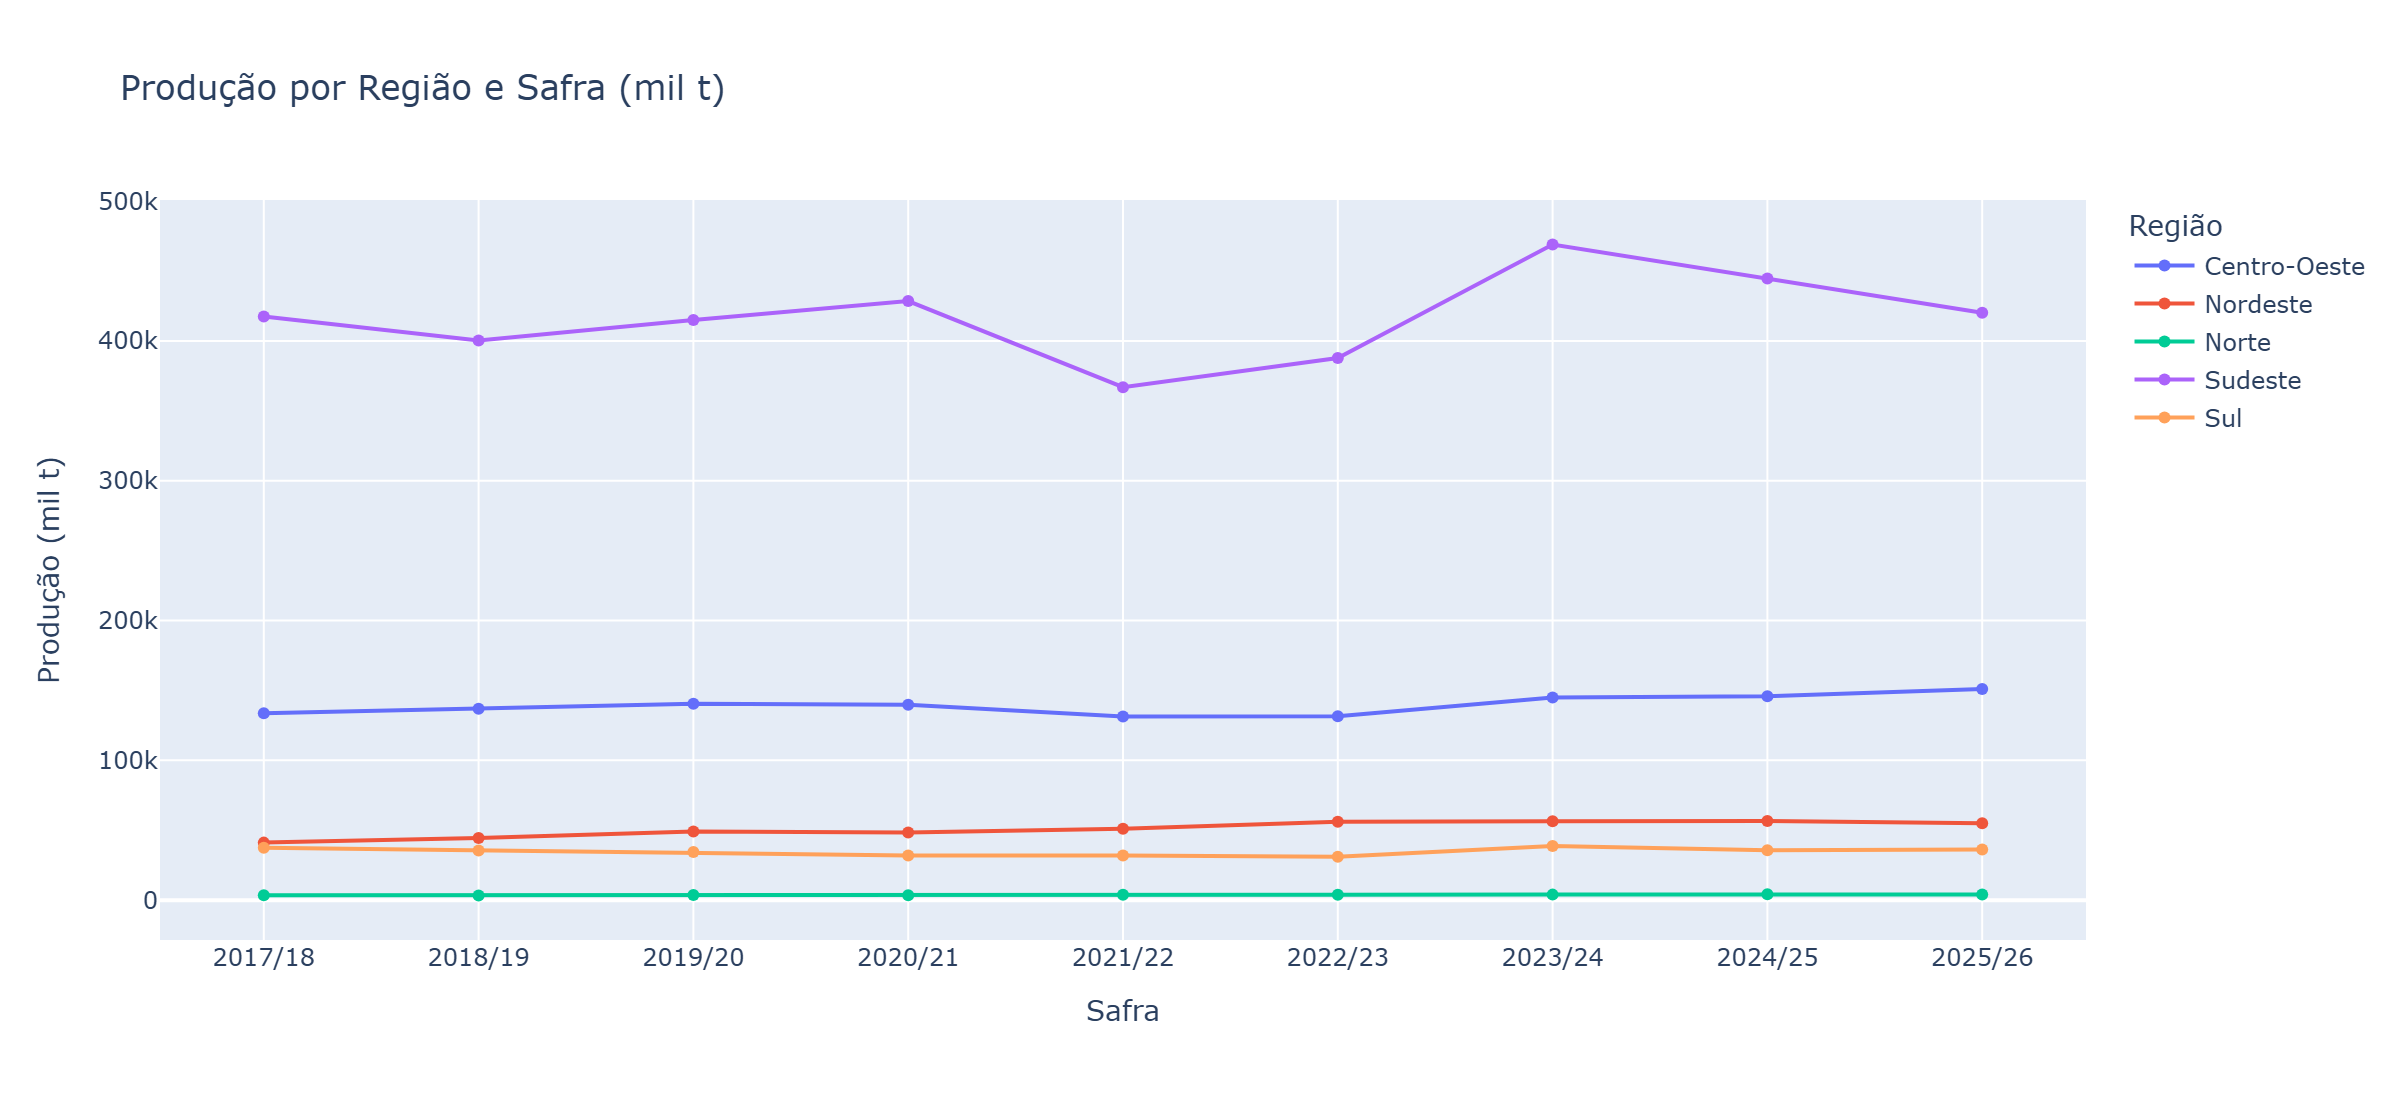

In [9]:
Image('../reports/figures/05_producao_por_regiao.png', width=800)

### 📌 Insights — Evolução da Produção por Região (2017/18 – 2025/26)

- **Sudeste** registrou **dominância absoluta** na série, com produção entre **366.929,8** e **469.026,9 mil t** — variação de ~102 mil t que expõe alta sensibilidade a ciclos adversos, com mínimo em 2021/22 e pico em 2023/24
- **Centro-Oeste** apresentou o crescimento mais **consistente e estável**, saindo de 133.664,1 para 151.030,4 mil t — avanço acumulado de ~13% com poucos desvios da trajetória ascendente
- **Nordeste** registrou o **maior crescimento relativo** da série: +34%, de 41.140,5 para 55.061,2 mil t — aceleração concentrada entre 2021/22 e 2023/24, com leve recuo em 2025/26
- **Sul** é a única região com **contração líquida no período** (-3,5%), atingindo mínimo de 30.953,1 mil t em 2022/23 e se recuperando parcialmente nos anos seguintes — ainda abaixo do nível inicial
- **Norte** mantém participação **marginal e estável**, crescendo ~15% no período, porém com volumes abaixo de 5 mil t — sem expansão estrutural relevante

> 💡 **Tendência geral:** produção nacional fortemente concentrada no Sudeste (~60%+ do total em todos os anos). O Nordeste se destaca como a região de maior dinamismo relativo, enquanto o Sul sinaliza contração que merece acompanhamento. Centro-Oeste consolida-se como segundo pilar produtivo com crescimento sustentado.

---

# 6. Precisão dos levantamentos

In [22]:
df_all['ano_agricola'] = df_all['ano_agricola'].str.strip()
df_all['uf'] = df_all['uf'].str.strip()
cols_n = ['area_plantada_mil_ha','producao_mil_t','producao_acucar_mil_t','producao_etanol_total_mil_l','produtcao_atr_kg_t']
for c in cols_n:
    df_all[c] = pd.to_numeric(df_all[c], errors='coerce').fillna(0)

lev1 = df_all[df_all['id_levantamento']==1][['ano_agricola','uf','producao_mil_t']].rename(columns={'producao_mil_t':'p1'})
levF = df_all[df_all['id_levantamento']==99][['ano_agricola','uf','producao_mil_t']].rename(columns={'producao_mil_t':'pF'})
comp = pd.merge(lev1, levF, on=['ano_agricola','uf'])
comp = comp[(comp['pF']>0) & (comp['p1']>0)]
comp['erro_pct'] = ((comp['pF'] - comp['p1']) / comp['pF'] * 100).abs()

fig = px.box(
    comp, x='uf', y='erro_pct',
    title='Variação % entre 1º Levantamento e Resultado Final por Estado',
    labels={'uf':'Estado','erro_pct':'Variação absoluta (%)'},
    color='uf'
)
fig.update_layout(showlegend=False)
fig.write_image('../reports/figures/06_variacao_levantamentos.png', width=1200, height=550, scale=2)
fig.show()

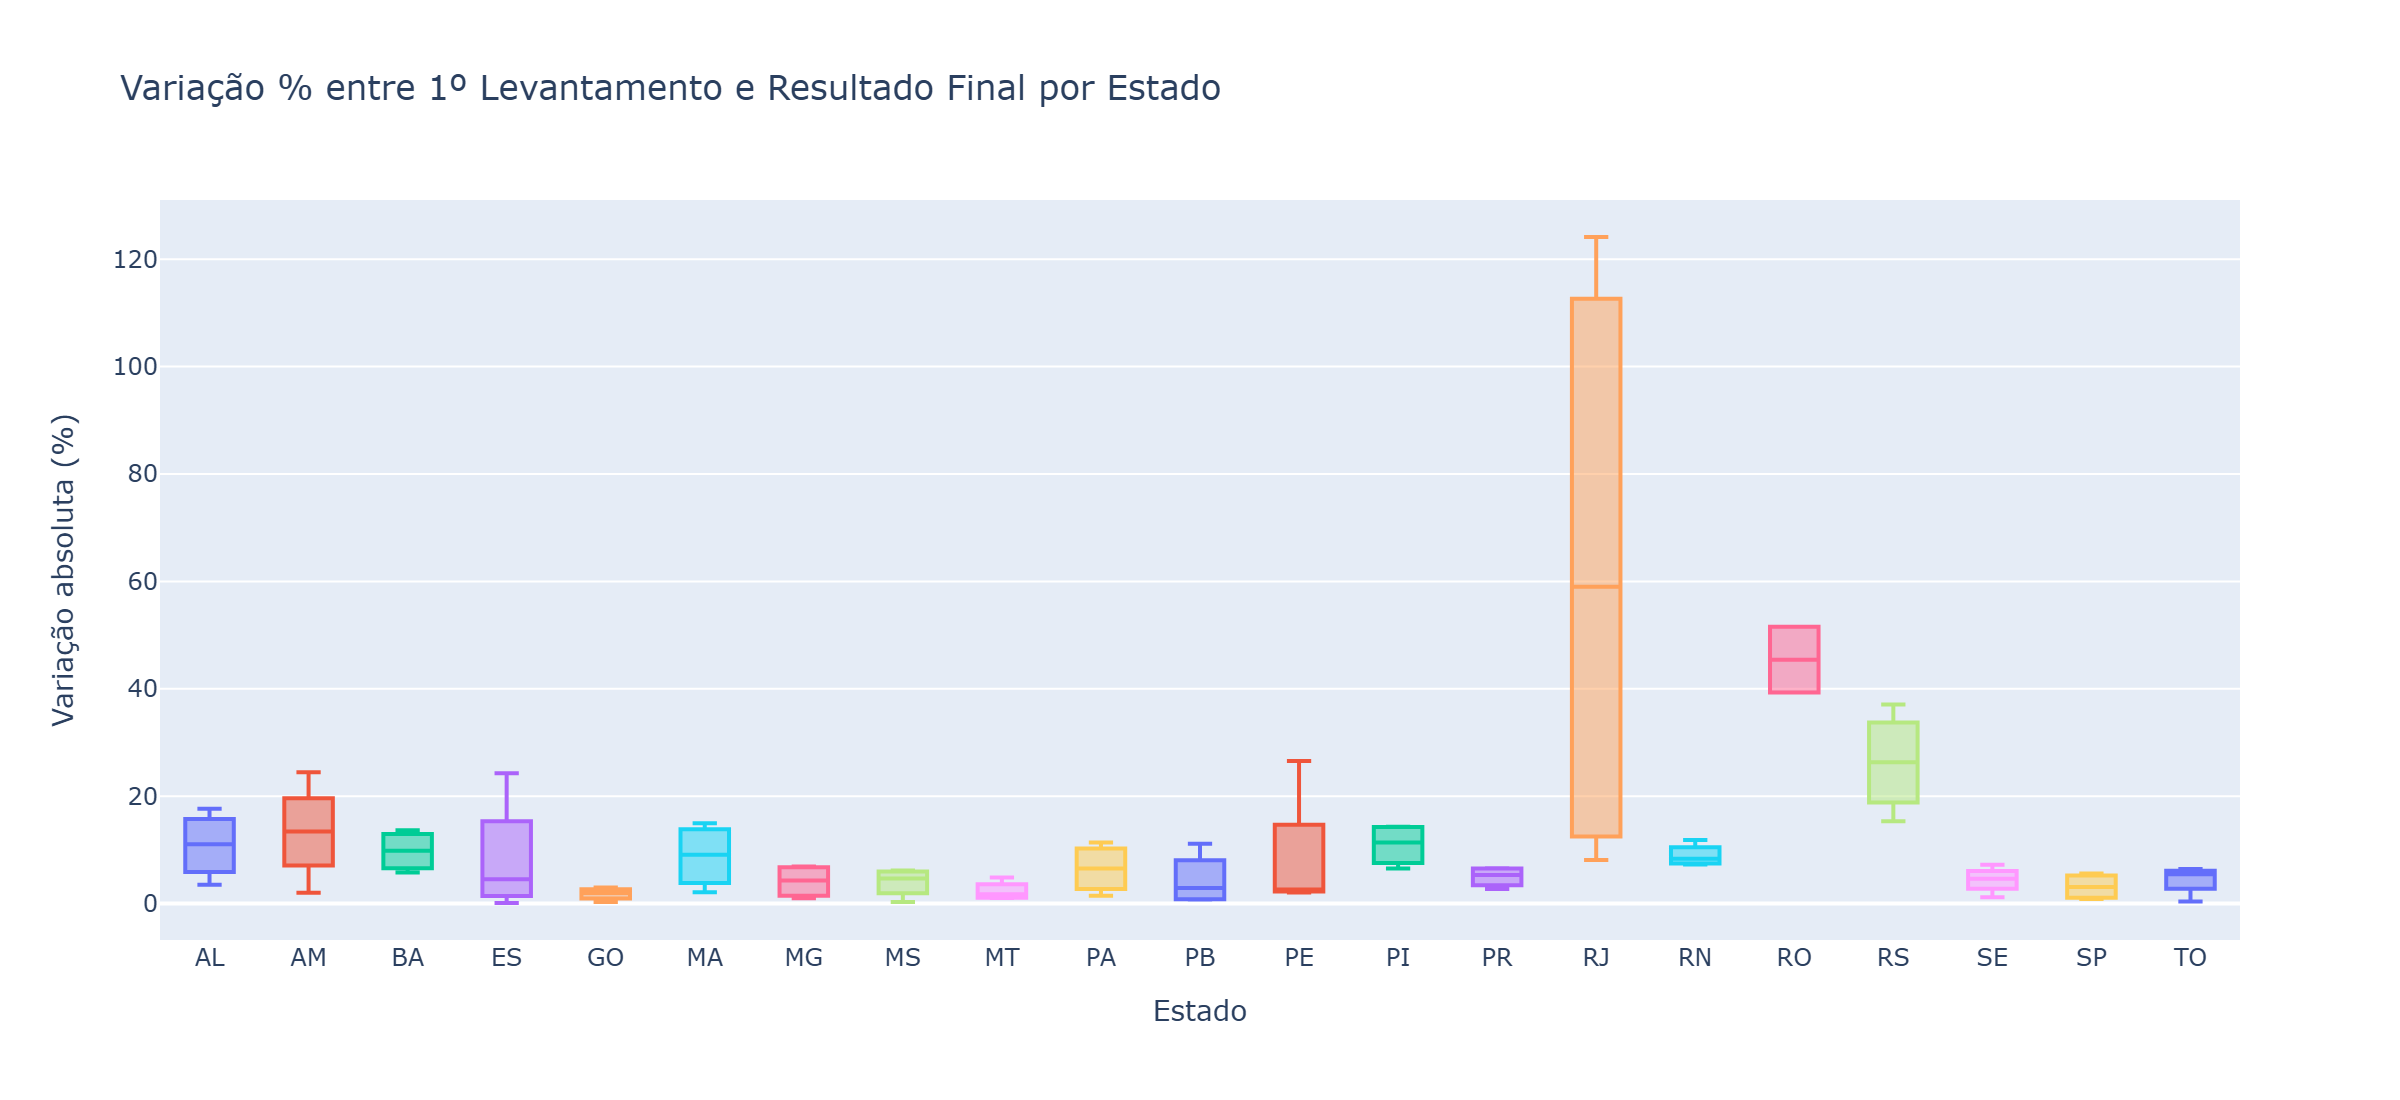

In [23]:
Image('../reports/figures/06_variacao_levantamentos.png', width=800)

### 📌 Insights — Variação % entre 1º Levantamento e Resultado Final por Estado

- **RJ** é o **outlier crítico** da série: mediana próxima a 55% e whisker superior acima de **120%** — valores 4 a 8x maiores que a maioria dos estados, indicando **inconsistência estrutural nas estimações iniciais**
- **RO e RS** formam o **segundo bloco de alta variabilidade**, com medianas em torno de 45% e 30% respectivamente — zonas de menor precisão preditiva com revisões frequentemente expressivas
- A **maioria dos estados** (AL, AM, BA, ES, GO, MA, PB, PE, entre outros) opera no **intervalo de 10–20%** de variação — padrão esperado com boxes compactos e boa capacidade preditiva já no 1º levantamento
- **SP, SE, PI e TO** registram as **menores variações absolutas** da série, com boxes abaixo de 10% — os estados mais confiáveis para projeções iniciais de safra
- **PE e AM** apresentam **assimetria superior** nos whiskers — boxes compactos, mas com picos positivos pontuais que indicam safras com surpresas favoráveis em anos específicos

> 💡 **Tendência geral:** a precisão dos levantamentos iniciais é heterogênea entre estados. RJ destaca-se como caso isolado de instabilidade. O grupo central opera com revisões previsíveis, enquanto SP e estados menores do Norte/Nordeste são os mais estáveis — o 1º levantamento já captura bem o resultado final nesses territórios.

---